In [4]:
import pandas as pd
from pathlib import Path
import sys
import yfinance as yf

sys.path.append("../../")

from black_scholes import *

For this project we have data from OptionsDX.
Here is a preview:

In [ ]:
try:
    df = pd.read_csv("2020/spx_eod_202001.txt")
except FileNotFoundError:
    print(
        """
        Error: missing data. The data .txt files are not included in the github repository due to repository size restrictions.
        The output required from running this file (processing.ipynb) should already exist in the /data directory.
        This file should no longer be necessary after the project is complete.
        If you have to run this notebook for some reason, download SPX EOD options data for the years specified below from
        https://www.optionsdx.com/product/spx-option-chain/.
        Then extract the zipped files and create a directory structure that looks like this:

        implied-stock-distributions/
        ├─ data/
        │  ├─ raw/
        │  │  ├─ 2020/
        │  │  │  ├─ spx_eod_202001.txt
        │  │  │  ├─ spx_eod_202002.txt
        │  │  │  └─ etc.
        │  │  ├─ 2021/
        │  │  │  ├─ spx_eod_202101.txt
        │  │  │  ├─ spx_eod_202102.txt
        │  │  │  └─ etc.
        │  │  ├─ etc.
        │  │  └─ processing.ipynb
        │  ├─ spx_options_2020.csv
        │  ├─ spx_options_2021.csv
        │  └─ etc.
        └─ project.ipynb
        """
    )
display(df)

,[QUOTE_UNIXTIME],[QUOTE_READTIME],[QUOTE_DATE],[QUOTE_TIME_HOURS],[UNDERLYING_LAST],[EXPIRE_DATE],[EXPIRE_UNIX],[DTE],[C_DELTA],[C_GAMMA],...,[P_LAST],[P_DELTA],[P_GAMMA],[P_VEGA],[P_THETA],[P_RHO],[P_IV],[P_VOLUME],[STRIKE_DISTANCE],[STRIKE_DISTANCE_PCT]
0,1577998800,2020-01-02 16:00,2020-01-02,16.0,3258.14,2020-01-03,1578085200,1.0,1.00000,0.00000,...,0.00,-0.00044,0.0,0.00100,-0.02473,0.00000,3.226840,,1858.1,0.570
1,1577998800,2020-01-02 16:00,2020-01-02,16.0,3258.14,2020-01-03,1578085200,1.0,1.00000,0.00000,...,0.05,0.00000,0.0,0.00155,-0.02480,0.00000,2.972420,20.000000,1758.1,0.540
2,1577998800,2020-01-02 16:00,2020-01-02,16.0,3258.14,2020-01-03,1578085200,1.0,1.00000,0.00000,...,0.00,-0.00032,0.0,0.00148,-0.02478,0.00000,2.733440,,1658.1,0.509
3,1577998800,2020-01-02 16:00,2020-01-02,16.0,3258.14,2020-01-03,1578085200,1.0,1.00000,0.00000,...,0.05,-0.00063,0.0,0.00145,-0.02458,-0.00016,2.510470,16.000000,1558.1,0.478
4,1577998800,2020-01-02 16:00,2020-01-02,16.0,3258.14,2020-01-03,1578085200,1.0,1.00000,0.00000,...,0.00,-0.00036,0.0,0.00115,-0.02531,0.00000,2.300260,,1458.1,0.448
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141022,1580504400,2020-01-31 16:00,2020-01-31,16.0,3224.93,2022-12-16,1671224400,1050.0,0.06871,0.00013,...,0.00,-1.00000,0.0,-11760.69979,0.00000,0.00000,,,1175.1,0.364
141023,1580504400,2020-01-31 16:00,2020-01-31,16.0,3224.93,2022-12-16,1671224400,1050.0,0.05396,0.00019,...,0.00,-1.00000,0.0,-12760.70021,0.00000,0.00000,,,1275.1,0.395
141024,1580504400,2020-01-31 16:00,2020-01-31,16.0,3224.93,2022-12-16,1671224400,1050.0,0.04295,0.00015,...,0.00,-1.00000,0.0,-13760.70017,0.00000,0.00000,,,1375.1,0.426
141025,1580504400,2020-01-31 16:00,2020-01-31,16.0,3224.93,2022-12-16,1671224400,1050.0,0.03415,0.00009,...,0.00,-1.00000,0.0,-14760.70006,0.00000,0.00000,,,1475.1,0.457


Below we'll do some cleaning and augment the dataset.
We'll make the following modifications:
- Remove columns that we don't need.
- Rename columns for convenience and readability.
- Filter for options with 7 or 28 day expiry times.
- Add columns for time to expiry in seconds and years.
- Add columns for the mid price of calls and puts.

NOTE: I actually don't think I'm going to do these:
- Add a column for the 13 week treasury bill (`^IRX`) that we'll use as a risk-free interest rate in our calculations.
- Replace the given implied volatility values with our own calculation.

/tmp/ipykernel_726418/3193395754.py:24: FutureWarning: YF.download() has changed argument auto_adjust default to True
  irx = yf.download("^IRX", start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^IRX,^IRX,^IRX,^IRX,^IRX
Date,,,,,
2010-01-04,0.055,0.080,0.055,0.080,0
2010-01-05,0.060,0.065,0.040,0.060,0
2010-01-06,0.045,0.060,0.045,0.060,0
2010-01-07,0.045,0.055,0.040,0.045,0
2010-01-08,0.040,0.045,0.035,0.045,0
...,...,...,...,...,...
2023-01-24,4.573,4.578,4.568,4.575,0
2023-01-25,4.545,4.565,4.545,4.563,0


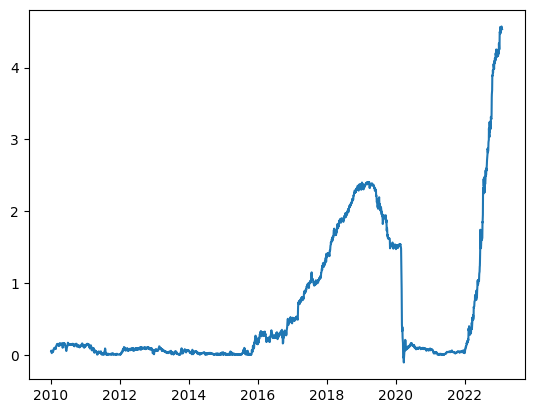

In [10]:
data_years = range(2010, 2024)
data_dirs = [Path(str(year)) for year in data_years]

newcols = {
    " [UNDERLYING_LAST]": "underlying_last",
    " [EXPIRE_UNIX]": "expire_unix",
    "[QUOTE_UNIXTIME]": "quote_unix",
    " [QUOTE_READTIME]": "quote_time",
    " [STRIKE]": "strike",
    " [C_IV]": "call_iv",
    " [C_BID]": "call_bid",
    " [C_ASK]": "call_ask",
    " [C_LAST]": "call_last",
    " [P_IV]": "put_iv",
    " [P_BID]": "put_bid",
    " [P_ASK]": "put_ask",
    " [P_LAST]": "put_last",
    " [DTE]": "dte"
    }

# Pull the data for ^IRX
start_date = str(min(data_years)) + "-01-01"
end_date = str(max(data_years)) + "-01-31"
irx = yf.download("^IRX", start=start_date, end=end_date)

display(irx)

import matplotlib.pyplot as plt

plt.plot(irx['Close'])



In [12]:
test_df = pd.read_csv("2020/spx_eod_202001.txt")
display(test_df)
test_df.columns

,[QUOTE_UNIXTIME],[QUOTE_READTIME],[QUOTE_DATE],[QUOTE_TIME_HOURS],[UNDERLYING_LAST],[EXPIRE_DATE],[EXPIRE_UNIX],[DTE],[C_DELTA],[C_GAMMA],...,[P_LAST],[P_DELTA],[P_GAMMA],[P_VEGA],[P_THETA],[P_RHO],[P_IV],[P_VOLUME],[STRIKE_DISTANCE],[STRIKE_DISTANCE_PCT]
0,1577998800,2020-01-02 16:00,2020-01-02,16.0,3258.14,2020-01-03,1578085200,1.0,1.00000,0.00000,...,0.00,-0.00044,0.0,0.00100,-0.02473,0.00000,3.226840,,1858.1,0.570
1,1577998800,2020-01-02 16:00,2020-01-02,16.0,3258.14,2020-01-03,1578085200,1.0,1.00000,0.00000,...,0.05,0.00000,0.0,0.00155,-0.02480,0.00000,2.972420,20.000000,1758.1,0.540
2,1577998800,2020-01-02 16:00,2020-01-02,16.0,3258.14,2020-01-03,1578085200,1.0,1.00000,0.00000,...,0.00,-0.00032,0.0,0.00148,-0.02478,0.00000,2.733440,,1658.1,0.509
3,1577998800,2020-01-02 16:00,2020-01-02,16.0,3258.14,2020-01-03,1578085200,1.0,1.00000,0.00000,...,0.05,-0.00063,0.0,0.00145,-0.02458,-0.00016,2.510470,16.000000,1558.1,0.478
4,1577998800,2020-01-02 16:00,2020-01-02,16.0,3258.14,2020-01-03,1578085200,1.0,1.00000,0.00000,...,0.00,-0.00036,0.0,0.00115,-0.02531,0.00000,2.300260,,1458.1,0.448
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141022,1580504400,2020-01-31 16:00,2020-01-31,16.0,3224.93,2022-12-16,1671224400,1050.0,0.06871,0.00013,...,0.00,-1.00000,0.0,-11760.69979,0.00000,0.00000,,,1175.1,0.364
141023,1580504400,2020-01-31 16:00,2020-01-31,16.0,3224.93,2022-12-16,1671224400,1050.0,0.05396,0.00019,...,0.00,-1.00000,0.0,-12760.70021,0.00000,0.00000,,,1275.1,0.395
141024,1580504400,2020-01-31 16:00,2020-01-31,16.0,3224.93,2022-12-16,1671224400,1050.0,0.04295,0.00015,...,0.00,-1.00000,0.0,-13760.70017,0.00000,0.00000,,,1375.1,0.426
141025,1580504400,2020-01-31 16:00,2020-01-31,16.0,3224.93,2022-12-16,1671224400,1050.0,0.03415,0.00009,...,0.00,-1.00000,0.0,-14760.70006,0.00000,0.00000,,,1475.1,0.457


Index(['[QUOTE_UNIXTIME]', ' [QUOTE_READTIME]', ' [QUOTE_DATE]',
       ' [QUOTE_TIME_HOURS]', ' [UNDERLYING_LAST]', ' [EXPIRE_DATE]',
       ' [EXPIRE_UNIX]', ' [DTE]', ' [C_DELTA]', ' [C_GAMMA]', ' [C_VEGA]',
       ' [C_THETA]', ' [C_RHO]', ' [C_IV]', ' [C_VOLUME]', ' [C_LAST]',
       ' [C_SIZE]', ' [C_BID]', ' [C_ASK]', ' [STRIKE]', ' [P_BID]',
       ' [P_ASK]', ' [P_SIZE]', ' [P_LAST]', ' [P_DELTA]', ' [P_GAMMA]',
       ' [P_VEGA]', ' [P_THETA]', ' [P_RHO]', ' [P_IV]', ' [P_VOLUME]',
       ' [STRIKE_DISTANCE]', ' [STRIKE_DISTANCE_PCT]'],
      dtype='object')

In [7]:
output_dir = ".." # csv files will be saved to this directory at the end

dfs = []

for dir in data_dirs:

    dfs = []

    print(f"Beginning to process data in {dir}/")
    for csv_path in dir.glob("*.txt"):
        
        # rename the columns for convenience
        df = pd.read_csv(csv_path)
        df.rename(columns=newcols, inplace=True)
        df = df[newcols.values()]

        # filter for options with 1 DTE, 7 DTE, or 28 DTE
        df = df[(df["dte"].isin([1, 7, 28]))]

        # add a column for time to expiry in seconds
        df['tte_unix'] = df['expire_unix'] - df['quote_unix']

        # add a column for the time to expiry in years
        df['tte_years'] = df['tte_unix']/(60*60*24*365)

        # make sure the quote time column is a datetime
        df['quote_time'] = pd.to_datetime(df['quote_time'])

        # make sure numeric columns are numeric
        numeric_columns = ["call_iv", "call_bid", "call_ask", "call_last", "put_iv", "put_bid", "put_ask", "put_last"]
        for col in numeric_columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

        # add a mid price for the options
        df['call_bid'] = pd.to_numeric(df['call_bid'], errors='coerce')
        df['call_ask'] = pd.to_numeric(df['call_ask'], errors='coerce')
        df['put_bid'] = pd.to_numeric(df['put_bid'], errors='coerce')
        df['put_ask'] = pd.to_numeric(df['put_ask'], errors='coerce')

        for option_type in ['call', 'put']:
            df[f'{option_type}_mid'] = (df[f'{option_type}_ask'] + df[f'{option_type}_bid'])/2

        # # replace the given IV values with our own calculation
        # df['call_iv'] = df.apply(
        #     lambda row: implied_volatility_call(
        #         market_price=row['call_mid'],
        #         S0 = row['underlying_last'],
        #         K=row['strike'],
        #         t=row['tte_years'],
        #         r=0.0
        #     ),
        #     axis=1
        # )

        # df['put_iv'] = df.apply(
        #     lambda row: implied_volatility_put(
        #         market_price=row['put_mid'],
        #         S0 = row['underlying_last'],
        #         K=row['strike'],
        #         t=row['tte_years'],
        #         r=0.0
        #     ),
        #     axis=1
        # )



        dfs.append(df)
        print(f"Added {len(df)} rows from {csv_path}.")

    big_df = pd.concat(dfs, ignore_index=True)
    big_df.to_csv(f"{output_dir}/spx_options_{dir}.csv", index=False)
        



Beginning to process data in 2010/
Added 711 rows from 2010/spx_eod_201009.txt.


/tmp/ipykernel_726418/1539756045.py:13: DtypeWarning: Columns (8,9,10,11,12,24,25,26,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


Added 525 rows from 2010/spx_eod_201011.txt.
Added 470 rows from 2010/spx_eod_201003.txt.
Added 521 rows from 2010/spx_eod_201004.txt.
Added 386 rows from 2010/spx_eod_201002.txt.


/tmp/ipykernel_726418/1539756045.py:13: DtypeWarning: Columns (8,9,10,11,12,15,17,18,20,21,23,24,25,26,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


Added 529 rows from 2010/spx_eod_201008.txt.
Added 360 rows from 2010/spx_eod_201005.txt.
Added 691 rows from 2010/spx_eod_201006.txt.
Added 735 rows from 2010/spx_eod_201012.txt.
Added 601 rows from 2010/spx_eod_201007.txt.
Added 543 rows from 2010/spx_eod_201001.txt.
Added 412 rows from 2010/spx_eod_201010.txt.
Beginning to process data in 2011/
Added 321 rows from 2011/spx_eod_201101.txt.


...

Added 10088 rows from 2022/spx_eod_202209.txt.
Added 6516 rows from 2022/spx_eod_202203.txt.
Beginning to process data in 2023/
Added 8375 rows from 2023/spx_eod_202311.txt.


/tmp/ipykernel_726418/1539756045.py:13: DtypeWarning: Columns (8,9,10,11,12,15,17,18,20,21,23,24,25,26,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


Added 10156 rows from 2023/spx_eod_202308.txt.
Added 9165 rows from 2023/spx_eod_202312.txt.
Added 7873 rows from 2023/spx_eod_202310.txt.
Added 7633 rows from 2023/spx_eod_202301.txt.
Added 8905 rows from 2023/spx_eod_202306.txt.
Added 8838 rows from 2023/spx_eod_202309.txt.
Added 8914 rows from 2023/spx_eod_202307.txt.
Added 7382 rows from 2023/spx_eod_202304.txt.
Added 6665 rows from 2023/spx_eod_202302.txt.


/tmp/ipykernel_726418/1539756045.py:13: DtypeWarning: Columns (8,9,10,11,12,15,17,18,20,21,23,24,25,26,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


Added 8651 rows from 2023/spx_eod_202305.txt.
Added 7636 rows from 2023/spx_eod_202303.txt.


In [9]:
# describe all the data:
for file in Path(output_dir).glob("spx_options_*.csv"):
    df = pd.read_csv(file)
    print(f"File: {file}")
    display(df.describe())

File: ../spx_options_2014.csv


,underlying_last,expire_unix,quote_unix,strike,call_iv,call_bid,call_ask,call_last,put_iv,put_bid,put_ask,put_last,dte,tte_unix,tte_years,call_mid,put_mid
count,22139.000000,2.213900e+04,2.213900e+04,22139.00000,10624.000000,22139.000000,22139.000000,22139.000000,21567.000000,22139.000000,22139.000000,22139.000000,22139.000000,2.213900e+04,22139.000000,22139.000000,22139.000000
mean,1939.799046,1.406188e+09,1.405213e+09,1688.34568,0.488174,270.404470,275.366356,16.744488,0.503569,21.922295,23.100867,4.042408,11.286914,9.751894e+05,0.030923,272.885413,22.511581
std,80.614869,9.178370e+06,9.114482e+06,299.54873,1.185719,276.427415,278.177701,66.718782,0.620085,56.137673,57.696433,17.025221,11.305180,9.767676e+05,0.030973,277.294497,56.912351
min,1773.100000,1.389388e+09,1.388783e+09,100.00000,-0.000440,0.000000,0.040000,0.000000,-0.000350,0.000000,0.040000,0.000000,1.000000,8.640000e+04,0.002740,0.020000,0.020000
25%,1865.050000,1.398456e+09,1.397246e+09,1525.00000,0.116020,33.490000,36.100000,0.000000,0.170160,0.000000,0.060000,0.000000,1.000000,8.640000e+04,0.002740,34.700000,0.030000
50%,1949.050000,1.406318e+09,1.405541e+09,1715.00000,0.173905,212.110000,219.800000,0.000000,0.337080,0.160000,0.440000,0.050000,7.000000,6.048000e+05,0.019178,215.910000,0.300000
75%,2001.550000,1.413490e+09,1.412885e+09,1905.00000,0.389975,408.550000,416.400000,0.100000,0.608785,7.100000,8.200000,0.600000,28.000000,2.419200e+06,0.076712,412.400000,7.645000
max,2089.220000,1.422047e+09,1.419973e+09,3000.00000,38.357090,1958.200000,1961.190000,1948.000000,11.759160,1160.800000,1162.900000,1018.250000,28.000000,2.419200e+06,0.076712,1959.695000,1161.850000


File: ../spx_options_2018.csv


,underlying_last,expire_unix,quote_unix,strike,call_iv,call_bid,call_ask,call_last,put_iv,put_bid,put_ask,put_last,dte,tte_unix,tte_years,call_mid,put_mid
count,64918.000000,6.491800e+04,6.491800e+04,64918.000000,51845.000000,64918.000000,64918.000000,64918.000000,55169.000000,64918.000000,64918.000000,64918.000000,64918.000000,6.491800e+04,64918.000000,64918.000000,64918.000000
mean,2743.341289,1.532044e+09,1.531050e+09,2538.074032,0.425703,270.250259,274.589609,43.680226,0.430841,65.724677,68.183247,21.134913,11.506839,9.941909e+05,0.031526,272.419934,66.953962
std,105.465005,9.092172e+06,9.028739e+06,429.699378,0.746074,363.538466,366.286408,160.540146,0.545830,128.888506,132.176591,61.494280,11.093250,9.584568e+05,0.030392,364.906500,130.525091
min,2351.100000,1.515013e+09,1.514927e+09,100.000000,-0.000500,0.000000,0.040000,0.000000,-0.000470,0.000000,0.040000,0.000000,1.000000,8.640000e+04,0.002740,0.020000,0.020000
25%,2673.480000,1.524686e+09,1.523650e+09,2350.000000,0.148320,1.650000,2.000000,0.000000,0.157360,0.060000,0.190000,0.000000,1.000000,8.640000e+04,0.002740,1.876250,0.125000
50%,2744.000000,1.532117e+09,1.531253e+09,2605.000000,0.238200,145.300000,150.200000,0.000000,0.281020,2.500000,2.750000,0.300000,7.000000,6.048000e+05,0.019178,147.677500,2.625000
75%,2815.670000,1.539634e+09,1.538597e+09,2820.000000,0.433180,385.900000,393.307500,5.990000,0.498950,74.900000,78.600000,7.200000,28.000000,2.419200e+06,0.076712,389.448750,76.650000
max,2931.210000,1.548709e+09,1.546290e+09,4000.000000,31.410450,2695.610000,2703.800000,2682.400000,12.809090,1572.410000,1577.600000,1540.150000,28.000000,2.419200e+06,0.076712,2699.705000,1575.005000


File: ../spx_options_2023.csv


...

,underlying_last,expire_unix,quote_unix,strike,call_iv,call_bid,call_ask,call_last,put_iv,put_bid,put_ask,put_last,dte,tte_unix,tte_years,call_mid,put_mid
count,16136.000000,1.613600e+04,1.613600e+04,16136.000000,8674.000000,16136.000000,16136.000000,16136.000000,15622.000000,16136.000000,16136.000000,16136.000000,16136.000000,1.613600e+04,16136.000000,16136.000000,16136.000000
mean,1658.394238,1.374999e+09,1.374031e+09,1478.789043,0.437683,201.435183,204.468068,15.222873,0.461331,23.802662,24.805650,4.397690,11.205131,9.681234e+05,0.030699,202.951626,24.304156
std,100.727184,9.194924e+06,9.111255e+06,277.179957,1.006658,240.428319,241.837618,60.739375,0.688769,56.414395,57.594226,24.056971,11.279900,9.745833e+05,0.030904,241.127130,57.000249
min,1459.070000,1.357333e+09,1.357247e+09,100.000000,-0.000470,0.000000,0.040000,0.000000,-0.000460,0.000000,0.040000,0.000000,1.000000,8.640000e+04,0.002740,0.020000,0.020000
25%,1588.400000,1.367611e+09,1.366402e+09,1350.000000,0.120505,10.500000,11.800000,0.000000,0.140115,0.000000,0.050000,0.000000,1.000000,8.640000e+04,0.002740,11.203750,0.025000
50%,1658.550000,1.375474e+09,1.374178e+09,1515.000000,0.166880,134.010000,137.300000,0.000000,0.274010,0.250000,0.500000,0.000000,7.000000,6.048000e+05,0.019178,135.697500,0.375000
75%,1722.240000,1.382040e+09,1.381435e+09,1660.000000,0.332145,291.892500,297.602500,0.330000,0.519763,15.292500,16.800000,0.650000,28.000000,2.419200e+06,0.076712,294.912500,16.015000
max,1841.870000,1.390597e+09,1.388437e+09,3000.000000,26.591230,1710.000000,1712.500000,1675.500000,11.611370,1223.410000,1225.500000,1224.300000,28.000000,2.419200e+06,0.076712,1711.250000,1224.455000


File: ../spx_options_2020.csv


,underlying_last,expire_unix,quote_unix,strike,call_iv,call_bid,call_ask,call_last,put_iv,put_bid,put_ask,put_last,dte,tte_unix,tte_years,call_mid,put_mid
count,82088.000000,8.208800e+04,8.208800e+04,82088.000000,61743.000000,82088.000000,82088.000000,82088.000000,74482.000000,82088.000000,82088.000000,82088.000000,82088.000000,8.208800e+04,82088.000000,82088.000000,82088.000000
mean,3182.313679,1.594559e+09,1.593639e+09,2946.330341,0.646058,379.071112,382.556761,125.538474,0.569796,144.822175,147.459587,58.863132,10.643322,9.195830e+05,0.029160,380.813936,146.140881
std,349.841837,8.934497e+06,8.888613e+06,693.903590,1.307259,524.523879,526.674630,281.164389,0.691048,291.649992,294.863236,160.516159,10.789766,9.322357e+05,0.029561,525.594216,293.238440
min,2235.760000,1.578085e+09,1.577999e+09,100.000000,-0.000470,0.000000,0.040000,0.000000,-0.000450,0.000000,0.040000,0.000000,1.000000,8.640000e+04,0.002740,0.020000,0.020000
25%,2948.610000,1.586981e+09,1.585858e+09,2600.000000,0.215510,3.300000,3.900000,0.000000,0.221550,0.110000,0.250000,0.050000,1.000000,8.640000e+04,0.002740,3.600000,0.180000
50%,3258.140000,1.594238e+09,1.593202e+09,3020.000000,0.345580,182.205000,186.200000,1.200000,0.379675,8.810000,9.300000,0.950000,7.000000,6.048000e+05,0.019178,184.195000,9.100000
75%,3399.030000,1.601928e+09,1.600978e+09,3370.000000,0.638800,524.400000,530.400000,138.180000,0.670815,141.702500,145.900000,33.642500,28.000000,2.419200e+06,0.076712,527.415000,143.895000
max,3735.560000,1.611781e+09,1.609362e+09,5600.000000,39.847500,3617.300000,3622.400000,3618.440000,13.721780,2094.610000,2104.500000,2241.220000,28.000000,2.419200e+06,0.076712,3619.850000,2099.555000


File: ../spx_options_2019.csv


,underlying_last,expire_unix,quote_unix,strike,call_iv,call_bid,call_ask,call_last,put_iv,put_bid,put_ask,put_last,dte,tte_unix,tte_years,call_mid,put_mid
count,67174.000000,6.717400e+04,6.717400e+04,67174.000000,50414.000000,67168.000000,67168.000000,67168.000000,58510.000000,67168.000000,67168.000000,67168.000000,67174.000000,6.717400e+04,67174.000000,67168.000000,67168.000000
mean,2912.836723,1.563051e+09,1.562067e+09,2664.086105,0.463582,305.581726,309.267441,47.970533,0.423240,57.667945,59.294425,15.752802,11.384152,9.835907e+05,0.031189,307.424584,58.481185
std,160.112817,9.304159e+06,9.239649e+06,467.750766,0.868719,384.968116,387.549874,163.763700,0.538064,126.023031,128.290268,60.831508,11.080459,9.573516e+05,0.030357,386.255486,127.151935
min,2446.850000,1.546636e+09,1.546463e+09,100.000000,-0.000500,0.000000,0.040000,0.000000,-0.000280,0.000000,0.040000,0.000000,1.000000,8.640000e+04,0.002740,0.020000,0.020000
25%,2822.430000,1.555099e+09,1.554235e+09,2440.000000,0.138280,5.310000,5.700000,0.000000,0.152523,0.000000,0.100000,0.000000,1.000000,8.640000e+04,0.002740,5.503750,0.050000
50%,2923.840000,1.563394e+09,1.562357e+09,2730.000000,0.223000,179.100000,183.400000,0.000000,0.264255,1.300000,1.440000,0.150000,7.000000,6.048000e+05,0.019178,181.250000,1.355000
75%,3004.520000,1.570824e+09,1.569614e+09,2975.000000,0.442263,444.425000,450.400000,16.052500,0.485787,54.500000,56.900000,3.950000,28.000000,2.419200e+06,0.076712,447.301250,55.651250
max,3240.070000,1.580159e+09,1.577740e+09,4800.000000,30.539390,3101.800000,3108.100000,3103.160000,13.259120,1839.790000,1845.800000,1761.360000,28.000000,2.419200e+06,0.076712,3104.950000,1842.795000


In [5]:
df = pd.read_csv(f"{output_dir}/spx_options_2020.csv")

In [6]:
display(df)

,underlying_last,expire_unix,quote_unix,quote_time,strike,call_iv,call_bid,call_ask,call_last,put_iv,put_bid,put_ask,put_last,dte,tte_unix,tte_years,call_mid,put_mid
0,3002.74,1583355600,1583269200,2020-03-03 16:00:00,1800.0,4.69707,1200.81,1210.10,1210.6,2.00098,0.00,0.05,0.10,1.0,86400,0.002740,1205.455,0.025
1,3002.74,1583355600,1583269200,2020-03-03 16:00:00,1900.0,NaN,1097.10,1107.30,1130.7,1.79853,0.00,0.05,0.05,1.0,86400,0.002740,1102.200,0.025
2,3002.74,1583355600,1583269200,2020-03-03 16:00:00,1950.0,3.83174,1050.80,1060.11,0.0,1.70212,0.00,0.05,0.00,1.0,86400,0.002740,1055.455,0.025
3,3002.74,1583355600,1583269200,2020-03-03 16:00:00,2000.0,NaN,995.10,1005.40,1102.6,1.60686,0.00,0.05,0.05,1.0,86400,0.002740,1000.250,0.025
4,3002.74,1583355600,1583269200,2020-03-03 16:00:00,2050.0,NaN,945.60,955.79,0.0,1.51524,0.00,0.05,0.05,1.0,86400,0.002740,950.695,0.025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82083,3624.23,1609189200,1606770000,2020-11-30 16:00:00,5000.0,0.34457,0.00,0.10,0.0,0.72737,1379.59,1389.40,0.00,28.0,2419200,0.076712,0.050,1384.495
82084,3624.23,1609189200,1606770000,2020-11-30 16:00:00,5100.0,0.37508,0.00,0.15,0.0,0.73548,1465.20,1490.51,0.00,28.0,2419200,0.076712,0.075,1477.855
82085,3624.23,1609189200,1606770000,2020-11-30 16:00:00,5200.0,0.36511,0.00,0.04,0.0,0.82286,1579.50,1589.30,0.00,28.0,2419200,0.076712,0.020,1584.400
82086,3624.23,1609189200,1606770000,2020-11-30 16:00:00,5300.0,0.38338,0.00,0.05,0.0,0.87009,1679.51,1689.30,0.00,28.0,2419200,0.076712,0.025,1684.405
